# Algorytm symulowanego wyżarzania

Symulowane wyżarzanie (*simulated annealing*) to probabilistyczna technika optymalizacyjna inspirowana procesem wyżarzania w metalurgii. Naśladuje fizyczny proces podgrzewania i powolnego schładzania materiału w celu usunięcia defektów. W kontekście optymalizacji „temperatura” jest skalarnym parametrem algorytmu. 

## Ogólny zarys
Rozpoczyna się od dowolnie wybranego początkowego rozwiązania i wysokiej temperatury, która jest stopniowo obniżana. Na każdym kroku algorytm losowo modyfikuje bieżące rozwiązanie w celu wygenerowania nowego kandydata. Jeśli nowe rozwiązanie jest lepsze, zostaje zaakceptowane. Jeśli jest gorsze, może również zostać zaakceptowane z pewnym prawdopodobieństwem, które jest proporcjonalne do temperatury. Pozwala to algorytmowi uniknąć lokalnych ekstremów i z czasem przybliżyć rozwiązanie optymalne w skali globalnej.

Tutaj zostanie przedstawiona podstawowa wersja tego algorytmu. Składa się z dwóch pętli. Pierwsza z nich, zewnętrzna, zarządza zmianą temperatury. Druga, wewnętrzna, determinuje ile sąsiadów jest sprawdzanych dla danej temperatury. Dobrą praktyką jest sprawdzenie wszystkich zmiennych w każdym kroku temperatury. Poniżej jest zaprezentowany pseudokod: 


![sa_pseudocode](../pliki_pomocnicze/pictures/sa_pseudocode.png)


Jako funkcji $P(\Delta E, \beta)$ użyjemy tzw. kryterium Metropolisa–Hastingsa:
$$
P(\Delta E, \beta) = \left\{
                            \begin{array}{ll}
                            1, & \text{jeżeli } \Delta E \leq 0 \\
                            e^{-\beta \Delta E}, & \text{w pozostałych przypadkach}
                            \end{array}
                            \right.
$$


Warto tutaj wspomnieć, że dla "wystarczająco powolnej" funkcji schładzającej istnieją matematyczne gwarancje osiągnięcia optymalnego wyniku. Jednakże czas i ilość kroków potrzebna by tą gwarancję osiągnąć często przekracza wyczerpujące przeszukiwanie.


In [5]:
from setup import setup_paths
setup_paths()

from funkcje_pomocnicze import read_instance, small_grid, P2, small_pegasus, calculate_energy

instance = small_pegasus

J, h = read_instance(instance.path)

print("nazwa instancji: ", instance.name)
print("ilość spinów: ", instance.spins)
print("najlepsza energia: ", instance.best_energy)




nazwa instancji:  P2
ilość spinów:  24
najlepsza energia:  -39.0


In [24]:
# Implementacja algorytmu symulowanego wyżarzania razem z funkcjami pomocniczymi
from setup import setup_paths
setup_paths()

import numpy as np
from math import exp
from funkcje_pomocnicze import calculate_energy


def acceptance_probability(delta_e: float, temp: float):
    if delta_e < 0:
        return 1
    else:
        beta = 1/temp
        probability = exp(-beta * delta_e)
        
        return probability


def calculate_delta_e(J, h, idx, state):
    s_k = state[idx]
    sum_j = J[idx, :] @ state.T
    return 2*s_k *(h[idx] + sum_j)


def get_temp(J, h):

    # W gorącej temperaturze chcemy by każdy spin mógł się zmienić z prawdopodobieństwem co najmniej 50%
    # rozwiązujemy:
    #   0.50 = exp(-hot_beta * max_delta_energy) 
    # rozwiązaniem jest hot_beta = log(2)/max_delta_energy, czyli T = max_delta_energy/log(2)
    # gdzie max_delta_energy = 2*max_effective_field, a max_effective_field = max_i (|h_i| + sum_j |J_ij|)

    h_abs = np.abs(h)
    J_abs = np.abs(J)
    values = [h_abs[i] + sum(J_abs[i, :]) for i in range(len(h))]
    max_effective_field = max(values)
    hot = (2*max_effective_field) / np.log(2)

    # w zimnej temp zakładamy że jesteśmy w minimum (lub stanie podstawowym) i chcemy ograniczyć
    # prawdopodobieństwo że jakikolwiek spin się zmieni. Dodatkowo dla uproszczenia, zakładamy że tylko 
    # spiny o minimalnej luce mogą wejść w stan wzbudzony. Rozwiązujemy:
    #   0.01 ~ #minimal_gaps exp(- cold_beta min_i min_delta_energy_i) 
    # gdzie #minimal_gaps to ilość przypadków o minimalnej luce energetycznej
    # min_delta_energy_i = min_i(min_delta_energy_i).
    # rozwiązaniem jest cold_beta = log(#minimal_gaps/0.01) / min_delta_energy czyli:
    # T =  min_delta_energy / log(#minimal_gaps/0.01)


    h_non_zero = h_abs[np.where(h_abs!=0)]
    def J_non_zero(A):
        return A[np.where(A!=0)]

    values_array = [min(h_non_zero[i], np.min(J_non_zero(J_abs[i, :]))) for i in range(len(h_non_zero))]
    min_effective_field = min(values_array)
    cold = (2*min_effective_field) / np.log(1/0.01)

    return hot, cold


In [25]:
# implementacja naiwna
from typing import Optional
from copy import deepcopy

def simulated_annealing_naive(J, h, num_steps: int, temp_range: Optional[tuple] = None, schedule: str = "linear"):
    # inicjalizacja
    n = len(h)
    solution = np.random.choice([-1, 1], size=n)
    energy = calculate_energy(J, h, solution)


    # Jeżeli temperatura nie była podana to jest dobierana automatycznie
    if not temp_range:
        T_0, T_final = get_temp(J, h)
    else:
        T_0, T_final = temp_range


    # Ustawiamy schedule
    if schedule == "linear":
        schedule = np.linspace(T_0, T_final, num=num_steps, endpoint=True)

    elif schedule == "exponential":
        schedule = np.geomspace(T_0, T_final, num=num_steps, endpoint=True)
    
    else:
        raise ValueError("Nieprawidłowy schedule")

    # główna pętla algorytmu
    for k in range(num_steps):
        temp = schedule[k]
        for idx in range(n):
    
            new_solution = deepcopy(solution)
            new_solution[idx] *= -1
            new_energy = calculate_energy(J, h, new_solution)
            delta_e = new_energy - energy

            r = np.random.random()
            
            if acceptance_probability(delta_e, temp) > r:
                solution = new_solution
                energy = new_energy


    return solution, energy
 

In [20]:
from setup import setup_paths
setup_paths()

from funkcje_pomocnicze import read_instance, small_grid, P2, small_pegasus, calculate_energy

instance = P4

J, h = read_instance(instance.path)

state, energy = simulated_annealing_naive(J, h, num_steps=100, schedule="exponential")

print(energy)

-363.0


Powyższa implementacja będzie działać sprawnie dla małych instancji, ale dla większych czas obliczeń bardzo szybko będzie rosnąć. Warto zauważyć, że w  głównej pętli występują dwa bardzo drogie operacje. Po pierwsze robimy głęboką kopie (`deepcopy`) stanu w każdym kroku. Ponadto dwa razy liczymy energię używając mnożenia macierzy.

By temu zaradzić, zauważamy, że intersuje nas róźnica energii pomiędzy rozwiązaniami ($\Delta E$), a nie ich dokładna wartość. 

$$
\Delta E_k = 2s_k \left( h_k + \sum_j J_{kj} s_j \right)
$$

Wyprowadzenie tego wzoru można znaleźć [tutaj](../pliki_pomocnicze/roznica_energii_wyprowadzenie.ipynb).

In [26]:
def simulated_annealing(J, h, num_steps: int, temp_range: Optional[tuple] = None, schedule: str = "linear"):
    # inicjalizacja
    n = len(h)
    solution = np.random.choice([-1, 1], size=n)
    energy = calculate_energy(J, h, solution)


    # Jeżeli temperatura nie była podana to jest dobierana automatycznie
    if not temp_range:
        T_0, T_final = get_temp(J, h)
    else:
        T_0, T_final = temp_range


    # Ustawiamy schedule
    if schedule == "linear":
        schedule = np.linspace(T_0, T_final, num=num_steps, endpoint=True)

    elif schedule == "exponential":
        schedule = np.geomspace(T_0, T_final, num=num_steps, endpoint=True)
    
    else:
        raise ValueError("Nieprawidłowy schedule")

    for k in range(num_steps):
        temp = schedule[k]
        for s in range(n):
            delta_e = calculate_delta_e(J, h, s, solution)
            r = np.random.random()

            if acceptance_probability(delta_e, temp) > r:
                solution[s] *= -1 
                energy += delta_e

    return solution, energy
 

wielokrone symulowane wyżarzanie:   0%|          | 0/20 [00:00<?, ?it/s]

wielokrone symulowane wyżarzanie: 100%|██████████| 20/20 [00:17<00:00,  1.13it/s]

Otrzymana energia: -469.0
Najniższa znana energia: -469.0
Luka energetyczna: -0.00%


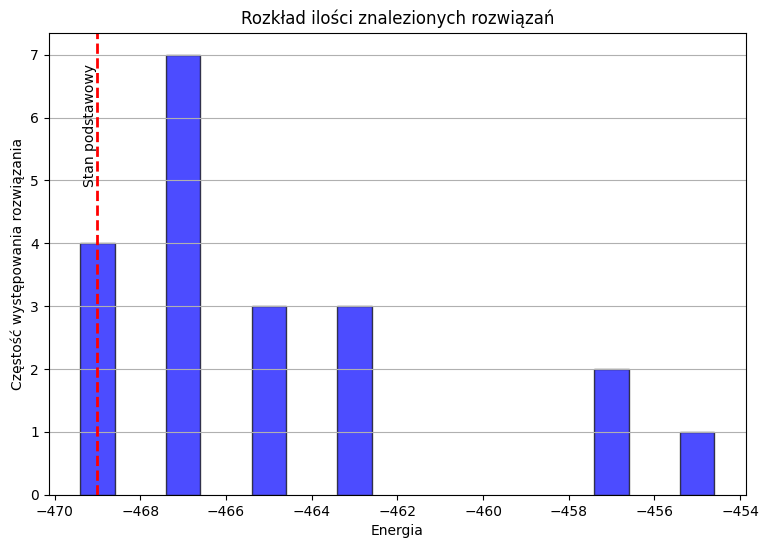

In [27]:
# Test dla małej instancji

import matplotlib.pyplot as plt
from funkcje_pomocnicze import read_instance, small_grid, test_pegasus, P8
from tqdm import tqdm

instance = test_pegasus

J, h = read_instance(instance.path)

# Ponieważ jest to probabilistyczny algorytm warto go puścić kilka razy i wybrać najlepszy wynik
energies = []
for _ in tqdm(range(20), desc="wielokrone symulowane wyżarzanie"):
    state, energy = simulated_annealing(J, h, num_steps=1000, schedule="exponential")
    energies.append(energy)

print(f"Otrzymana energia: {min(energies)}")
print(f"Najniższa znana energia: {instance.best_energy}")
print(f"Luka energetyczna: {((instance.best_energy - min(energies))/instance.best_energy * 100):.2f}%")

unique_values, counts = np.unique(energies, return_counts=True)


plt.figure(figsize=(9, 6))
plt.bar(unique_values, counts, color='blue', edgecolor='black', alpha=0.7)
#plt.xticks(energies)
plt.axvline(x=test_pegasus.best_energy, color='red', linestyle='--', linewidth=2)
plt.text(test_pegasus.best_energy, plt.ylim()[1]*0.8, 'Stan podstawowy', color='black', rotation=90,
         verticalalignment='center', horizontalalignment='right')

plt.xlabel("Energia")
plt.ylabel("Częstość występowania rozwiązania")
plt.title("Rozkład ilości znalezionych rozwiązań")
plt.grid(axis="y")
plt.show()



## Luka energetyczna

Przy porównywaniu różnych algorytmów (albo różnych implementacji tego samego algorytmu) przydaje się pojęcie **luki energetycznej** (ang. *gap*). Definiuje się ją jako:

$$
\text{luka energetyczna} = \frac{E_{\text{best} - E}}{E_{\text{best}}}
$$

gdzie $E_{\text{best}}$ jest najlepszą znaną energią dla danej instancji. W skrócie, jest to parametr który mówi nam o względnej różnic pomiędzy otrzymanym wynikiem a najlepszym znanym wynikiem.

## Zrównoleglenie

Przez to że algorytm sam w sobie jest stochastyczny nie mamy gwarancji że w trakcie jednego wywołania otrzymamy najlepszy możliwy wynik. Jedym z rozwiązać tego problemu jest zrównoleglenie algorytmu. Oznacza to, że jednocześnie śledzimy wiele "trajektorii" i na końcu obliczeń możemy wybrać najlepszą z nich. Można tego dokonać wywołując algorytm wielokrotnie, ale jest to nieefektywne. Lepszym rozwiązaniem jest trzymanie wielu stanów ułożonych w macierz. Niech $\sigma_i$ będzie stanem, wtedy mając $M$ trajektorii:

$$
\sigma = \begin{bmatrix}
\vert & \vert & \cdots & \vert \\
\sigma_1 & \sigma_2 & \cdots & \sigma_M \\
\vert & \vert & \cdots & \vert
\end{bmatrix}
$$

Wybór czy trzymamy stany w kolumnach czy w wierszach jest arbitralny. To podejście pozwala nam równolegle liczyć wiele rozwiązań.

Warto zwrócić uwagę, że w tej sytuacji zmiana stanu i prawdopodobieństwo jego zaakceptowania musi być liczone niezależnie dla każdej trajektorii.


In [28]:


def calculate_delta_e_matrix(J, h, idx, state, M):
    s_k = state[idx, :]  # <- wiersz
    h_k = np.array([h[idx]] * M)
    sum_j = J[idx, :] @ state
    return 2 * s_k * (h_k + sum_j)


def calculate_energy_matrix(J: np.ndarray, h: np.ndarray, state: np.ndarray, convention: str = "minus_half"):
    n, _ = J.shape
    if convention == "minus_half":
        A = np.multiply(-1 / 2, J)
        B = np.matmul(A, state) - h.reshape(n, 1)
        C = np.multiply(state, B)
    elif convention == "dwave":
        B = np.matmul(J, state) + h.reshape(n, 1)
        C = np.multiply(state, B)
    return np.sum(C, axis=0)


def acceptance_probability_vect(delta_e, temp, r):
    beta = 1 / temp
    prob = np.ones_like(delta_e)
    mask = delta_e >= 0
    prob[mask] = np.exp(-beta * delta_e[mask])
    accept = prob > r
    return accept


def simulated_annealing_multiple_trajectories(J, h, M: int, num_steps: int, temp_range: Optional[tuple] = None,
                               schedule: str = "linear"):
    # inicjalizacja
    n = len(h)
    solution = np.random.choice([-1, 1], size=(n, M))
    energy = calculate_energy_matrix(J, h, solution)

    # Jeżeli temperatura nie była podana to jest dobierana automatycznie
    if not temp_range:
        T_0, T_final = get_temp(J, h)
    else:
        T_0, T_final = temp_range

    # Ustawiamy schedule
    if schedule == "linear":
        schedule = np.linspace(T_0, T_final, num=num_steps, endpoint=True)

    elif schedule == "exponential":
        schedule = np.geomspace(T_0, T_final, num=num_steps, endpoint=True)

    else:
        raise ValueError("Nieprawidłowy schedule")

    for k in tqdm(range(num_steps), desc= "simulated annealing"):
        temp = schedule[k]
        for idx in range(n):
            delta_e = calculate_delta_e_matrix(J, h, idx, solution, M)
            r = np.random.random(M)
            mask = acceptance_probability_vect(delta_e, temp, r)

            solution[idx, mask] *= -1
            energy[mask] += delta_e[mask]

    return solution, energy

simulated annealing:   0%|          | 0/1000 [00:00<?, ?it/s]

simulated annealing: 100%|██████████| 1000/1000 [00:05<00:00, 174.65it/s]


Otrzymana energia: -469.0
Najniższa znana energia: -469.0
Luka energetyczna: -0.00%


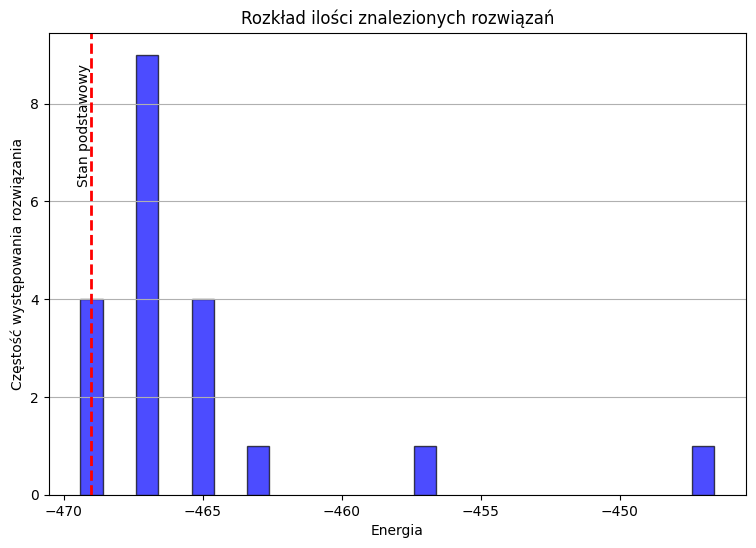

In [29]:
# Test dla małej instancji

import matplotlib.pyplot as plt
from funkcje_pomocnicze import read_instance, small_grid, test_pegasus, P8
from tqdm import tqdm

instance = test_pegasus

J, h = read_instance(instance.path)

# używamy wersji zrównoleglonej

states, energies = simulated_annealing_multiple_trajectories(J, h, 20, num_steps=1000, schedule="exponential")

print(f"Otrzymana energia: {min(energies)}")
print(f"Najniższa znana energia: {instance.best_energy}")
print(f"Luka energetyczna: {((instance.best_energy - min(energies))/instance.best_energy * 100):.2f}%")

unique_values, counts = np.unique(energies, return_counts=True)


plt.figure(figsize=(9, 6))
plt.bar(unique_values, counts, color='blue', edgecolor='black', alpha=0.7)
#plt.xticks(energies)
plt.axvline(x=test_pegasus.best_energy, color='red', linestyle='--', linewidth=2)
plt.text(test_pegasus.best_energy, plt.ylim()[1]*0.8, 'Stan podstawowy', color='black', rotation=90,
         verticalalignment='center', horizontalalignment='right')

plt.xlabel("Energia")
plt.ylabel("Częstość występowania rozwiązania")
plt.title("Rozkład ilości znalezionych rozwiązań")
plt.grid(axis="y")
plt.show()



## Porównanie wersji zrównoleglonej z naiwną



zbieranie_danych: 100%|██████████| 3/3 [03:03<00:00, 61.29s/it]


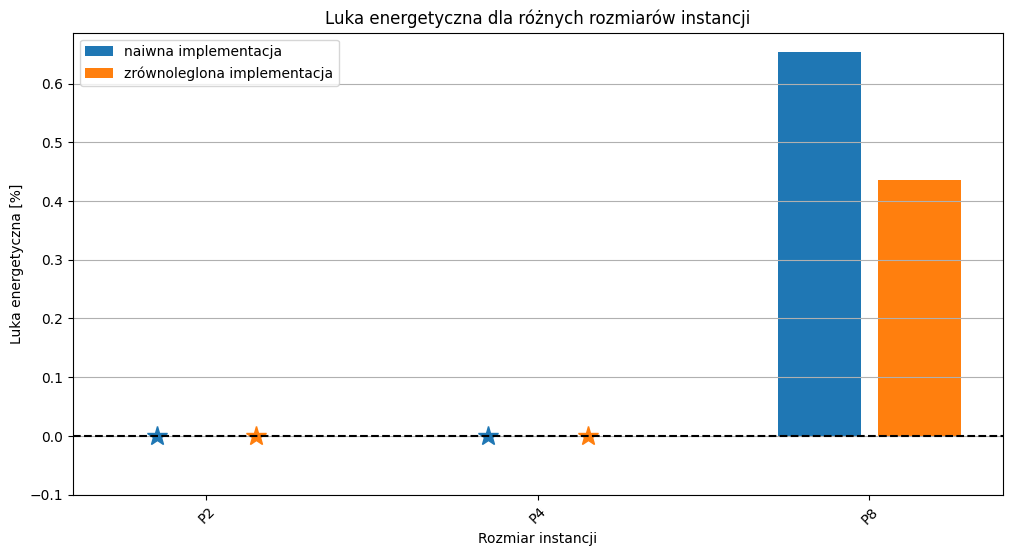

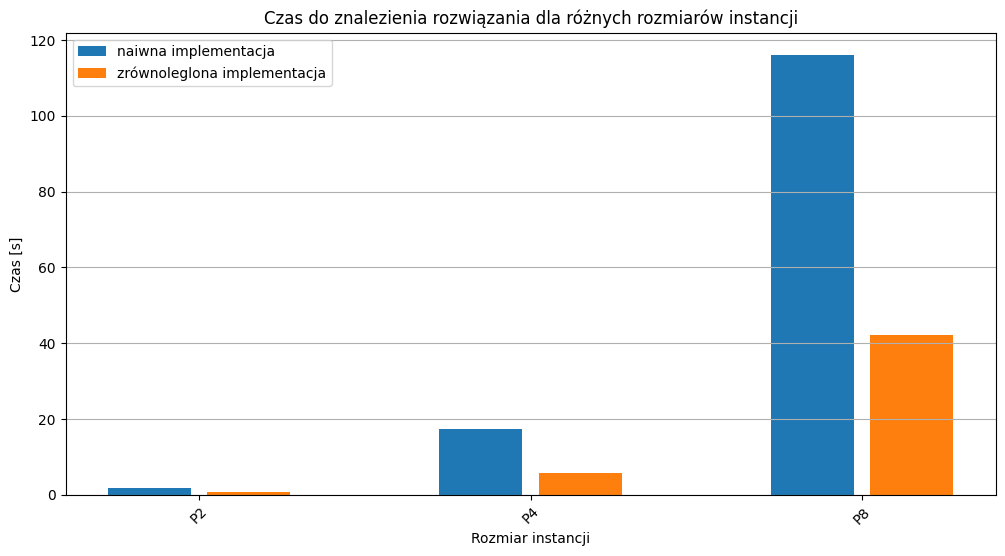

In [30]:

import time

import matplotlib.pyplot as plt
import numpy as np

from funkcje_pomocnicze import read_instance, P2, P4, P8, P12, P16
from tqdm import tqdm
from math import isclose
from IPython.utils.io import capture_output

num_reads = 20
gaps_naive = []
times_naive = []

gaps = []
times = []


for instance in tqdm([P2, P4, P8], desc="zbieranie_danych"):

    J1, h1 = read_instance(instance.path)
    
    begin = time.time()
    with capture_output() as captured:
        states, energies = simulated_annealing_multiple_trajectories(J1, h1, 20, num_steps=1000, schedule="exponential")
    end = time.time()
    sol = min(energies)
    times.append(end-begin)
    gaps.append((instance.best_energy - sol)/instance.best_energy * 100)

    energies = []
    begin = time.time()
    for _ in range(num_reads):
        state, energy = simulated_annealing(J1, h1, num_steps=1000, schedule="exponential")
        energies.append(energy)
    end = time.time()
    sol = min(energies)
    times_naive.append(end-begin)
    gaps_naive.append((instance.best_energy - sol)/instance.best_energy * 100)

fig, ax = plt.subplots(figsize=(12, 6))

instancje = ["P2", "P4", "P8"]

x = np.arange(len(instancje))
width = 0.25
offset = 0.15

bar1 = ax.bar(x - offset, gaps_naive, width, label="naiwna implementacja")
bar2 = ax.bar(x + offset, gaps, width, label="zrównoleglona implementacja")

barset = [bar1, bar2]
for bars in barset:
    for bar in bars:
        if isclose(bar.get_height(), 0):
            center = bar.get_x() + bar.get_width()/2
            ax.plot(center, 0, marker='*', markersize=15, color=bar.get_facecolor())

(y_min, y_max) = ax.get_ylim()
ax.set_ylim((-0.1, y_max))
ax.set_xlabel("Rozmiar instancji")
ax.set_xticks(x)
ax.set_xticklabels(instancje, rotation=45)
ax.set_ylabel("Luka energetyczna [%]")
ax.set_title("Luka energetyczna dla różnych rozmiarów instancji")
ax.axhline(0, color='black', linestyle='--')
#ax.axhline(1, color="red", linestyle="--")
ax.legend()

plt.grid(axis="y")
plt.show()

fig2, ax2 = plt.subplots(figsize=(12, 6))
bar1 = ax2.bar(x - offset, times_naive, width, label="naiwna implementacja")
bars = ax2.bar(x + offset, times, width, label="zrównoleglona implementacja")

ax2.set_xlabel("Rozmiar instancji")
ax2.set_xticks(x)
ax2.set_xticklabels(instancje, rotation=45)
ax2.set_ylabel("Czas [s]")
ax2.set_title("Czas do znalezienia rozwiązania dla różnych rozmiarów instancji")
ax2.legend()

plt.grid(axis="y")
plt.show()


### Heurystyczność

Trzeba tutaj podkreślić, że w wypadku używania algorytmów heurystycznych (np. symulowane wyżarzanie), ich skuteczność i wydajność w dużej mierze zależą od właściwego doboru hiperparametrów. Wybór tych parametrów jest procesem trudnym i często kosztowym obliczeniowo. Czasami prawdziwe trudności obliczeniowe są w ukryte właśnie za decyzjami związanymi z hiperparametryzacją. 

Zagadnienia te będą omawiane szerzej w kontekście bardziej złożonych algorytmów, w których pojawiają się dodatkowe aspekty, takie jak możliwość równoległego przetwarzania danych czy wykorzystanie mocy obliczeniowej GPU, co pozwala na znaczne przyspieszenie obliczeń, ale jednocześnie zwiększa złożoność całego procesu optymalizacji.

# Bibliografia

* Eglese, R.W. (1990). Simulated annealing: A tool for operational research. *European Journal of Operational Research*, Volume **46**, Issue **3**, 1990, DOI: [10.1016/0377-2217(90)90001-R](https://doi.org/10.1016/0377-2217(90)90001-R)

* Henderson, D., Jacobson, S.H., Johnson, A.W. (2003). The Theory and Practice of Simulated Annealing. In: Glover, F., Kochenberger, G.A. (eds) Handbook of Metaheuristics. International Series in Operations Research & Management Science, vol 57. Springer, Boston, MA. DOI: [10.1007/0-306-48056-5_10](https://doi.org/10.1007/0-306-48056-5_10)

* Vodeb, J., Eržen, V., Hrga, T., Povh, J. (2024). Accuracy and Performance Evaluation of Quantum, Classical and Hybrid Solvers for the Max-Cut Problem. *ArXiv preprint*, DOI: [10.48550/arXiv.2412.07460](https://doi.org/10.48550/arXiv.2412.07460)


# Dodatkowe materiały

* [Simulated annealing: From basics to applications](https://enac.hal.science/hal-01887543v1/document)
